In [2]:
!pip install -r requirements.txt

In [3]:
# Run this in a Jupyter cell first
with open("/home/mca/Shweta/handwritten text detection/dataset/Word_Level_English_Training_Set/Word_Level_Training_Set/train.txt") as f:
    lines = f.readlines()

print(f"Total lines: {len(lines)}")
print("First 10 lines:")
for line in lines[:10]:
    print(repr(line))

Total lines: 85020
First 10 lines:
'image/39254_1.jpg\t13113\n'
'image/39254_2.jpg\tAnd\n'
'image/39254_3.jpg\tin\n'
'image/39254_4.jpg\tJanuary\n'
'image/39254_5.jpg\tthey\n'
'image/39254_6.jpg\tAnd\n'
'image/39254_7.jpg\tin\n'
'image/39254_8.jpg\tthe\n'
'image/39254_9.jpg\tbattle\n'
'image/39254_10.jpg\tdefeated\n'


In [2]:
import sys
sys.path.insert(0, "/home/mca/Shweta/handwritten text detection/hvlt")   # folder containing train.py

from train import run_single_seed, get_config

# Manually set config instead of argparse
import argparse
cfg = argparse.Namespace(
    train_txt  = "/home/mca/Shweta/handwritten text detection/dataset/Word_Level_English_Training_Set/Word_Level_Training_Set/train.txt",
    root_dir   = "/home/mca/Shweta/handwritten text detection/dataset/Word_Level_English_Training_Set/Word_Level_Training_Set",
    val_split  = 0.15,
    img_height = 32,
    img_width  = 128,
    num_fiducial     = 16,
    d_model          = 768,
    n_heads          = 12,
    n_layers         = 12,
    vis_seq_len      = 256,
    acg_dropout      = 0.3,
    acg_lambda       = 0.1,
    no_pretrained_swin    = False,
    no_pretrained_roberta = False,
    batch_size   = 32,
    lr           = 5e-5,
    max_epochs   = 10,
    patience     = 3,
    seeds        = [42],
    use_amp      = True,
    num_workers  = 4,
    output_dir   = "outputs/",
    log_every    = 50,
)

result = run_single_seed(cfg, seed=42, run_idx=0)
print(result)


  Run 1/3  |  Seed: 42
  Device: cuda

[1/4] Loading data...
  Loaded 85020 samples from /home/mca/Shweta/handwritten text detection/dataset/Word_Level_English_Training_Set/Word_Level_Training_Set/train.txt
  Train samples: 72267 | Val samples: 12753

[2/4] Building HVLT model...


/home/mca/Shweta/handwritten text detection/sbenv/lib/python3.12/site-packages/timm/layers/interpolate.py:47: UserWarning: torch.searchsorted(): input value tensor is non-contiguous, this will lower the performance due to extra data copy when converting non-contiguous tensor to contiguous, please use contiguous input value tensor if possible. This message will only appear once per program. (Triggered internally at /pytorch/aten/src/ATen/native/BucketizationUtils.h:32.)
  idx_right = torch.bucketize(x, p)
/home/mca/Shweta/handwritten text detection/sbenv/lib/python3.12/site-packages/timm/layers/interpolate.py:65: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:34

  Loading RoBERTa-base weights...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  RoBERTa initialization complete.
  Parameters: 163.3M

[3/4] Training...
  NOTE: Paper finds optimal checkpoint at Epoch 3.
        WAR-based early stopping will handle this automatically.


─── Epoch 1/10 (seed=42) ───


OutOfMemoryError: CUDA out of memory. Tried to allocate 20.00 MiB. GPU 0 has a total capacity of 31.47 GiB of which 47.81 MiB is free. Process 2462 has 314.57 MiB memory in use. Process 265417 has 4.87 GiB memory in use. Process 741007 has 3.36 GiB memory in use. Process 266254 has 3.63 GiB memory in use. Process 1364896 has 6.12 GiB memory in use. Process 1390780 has 4.02 GiB memory in use. Process 1412115 has 4.07 GiB memory in use. Including non-PyTorch memory, this process has 3.71 GiB memory in use. Of the allocated memory 3.33 GiB is allocated by PyTorch, and 9.77 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

In [2]:
import sys
sys.path.insert(0, "/home/mca/Shweta/handwritten text detection/hvlt")

import torch
from models.hvlt import HVLT
from data.dataset import get_dataloaders, decode_tokens

# Load checkpoint
ckpt = torch.load("outputs/seed_42/best_model.pt", map_location="cuda")

model = HVLT(
    img_height=32, img_width=128, num_fiducial=16,
    d_model=768, n_heads=12, n_layers=12, vis_seq_len=256,
    acg_dropout=0.3, pretrained_swin=False, pretrained_roberta=False,
).cuda()

model.load_state_dict(ckpt["model_state"])
model.eval()
print(f"Loaded epoch {ckpt['epoch']} | val_CAR={ckpt['val_car']:.2f}% | val_WAR={ckpt['val_war']:.2f}%")

# Reload val loader
_, val_loader = get_dataloaders(
    train_txt="/home/mca/Shweta/handwritten text detection/dataset/Word_Level_English_Training_Set/Word_Level_Training_Set/train.txt",
    root_dir="/home/mca/Shweta/handwritten text detection/dataset/Word_Level_English_Training_Set/Word_Level_Training_Set",
    val_split=0.15, batch_size=8, num_workers=0,
)

# Run diagnostic
images, targets, labels = next(iter(val_loader))
images  = images.cuda()
targets = targets.cuda()

with torch.no_grad():
    logits, acg_gate = model(images, targets)
    pred_ids = logits.argmax(dim=-1)

for i in range(4):
    pred_text = decode_tokens(pred_ids[i].cpu().tolist())
    print(f"GT: '{labels[i]}' | Pred: '{pred_text}'")

Loaded epoch 10 | val_CAR=98.06% | val_WAR=93.25%
  Loaded 85020 samples from /home/mca/Shweta/handwritten text detection/dataset/Word_Level_English_Training_Set/Word_Level_Training_Set/train.txt
  Train samples: 72267 | Val samples: 12753
GT: 'father' | Pred: 'father'
GT: 'He' | Pred: 'He'
GT: 'in' | Pred: 'in'
GT: '77' | Pred: '77'


  Loaded 85020 samples from /home/mca/Shweta/handwritten text detection/dataset/Word_Level_English_Training_Set/Word_Level_Training_Set/train.txt
  Train samples: 72267 | Val samples: 12753
Val image shape: torch.Size([8, 3, 32, 128])
Val image min/max: -1.8952821493148804 1.9951199293136597
Val labels: ['father', 'He', 'in', '77', 'ended', 'the', 'First', 'to']

Train labels: ['49284', '26', '15589', 'against', 'will', 'only', 'member', 'ifa']


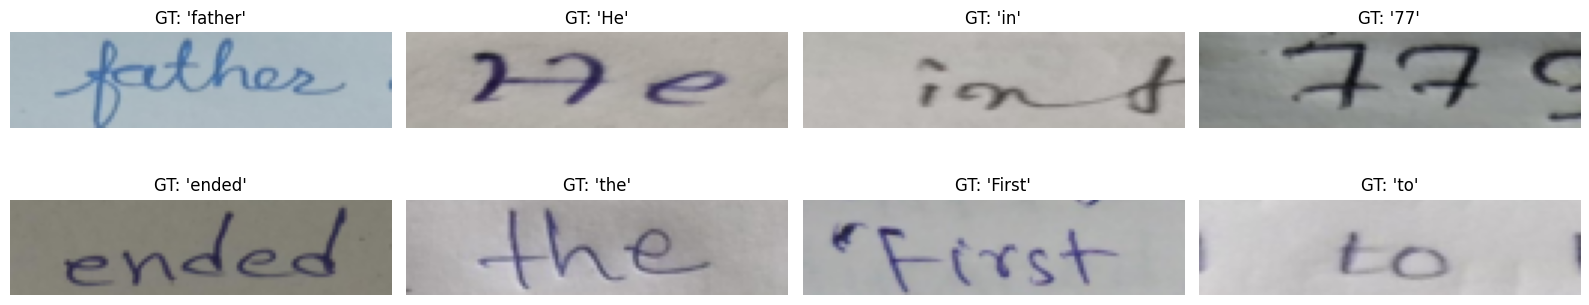

In [2]:
import importlib
import data.dataset
importlib.reload(data.dataset)
from data.dataset import get_dataloaders
import matplotlib.pyplot as plt
import torch

train_loader, val_loader = get_dataloaders(
    train_txt="/home/mca/Shweta/handwritten text detection/dataset/Word_Level_English_Training_Set/Word_Level_Training_Set/train.txt",
    root_dir="/home/mca/Shweta/handwritten text detection/dataset/Word_Level_English_Training_Set/Word_Level_Training_Set",
    val_split=0.15,
    batch_size=8,
    num_workers=0,
)

# Check a val batch
images, targets, labels = next(iter(val_loader))
print("Val image shape:", images.shape)
print("Val image min/max:", images.min().item(), images.max().item())
print("Val labels:", labels[:8])

# Check a train batch
images_t, targets_t, labels_t = next(iter(train_loader))
print("\nTrain labels:", labels_t[:8])

# Visualize val images
fig, axes = plt.subplots(2, 4, figsize=(16, 4))
mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
for i, ax in enumerate(axes.flat):
    img = images[i] * std + mean  # unnormalize
    img = img.permute(1,2,0).clamp(0,1).numpy()
    ax.imshow(img)
    ax.set_title(f"GT: '{labels[i]}'")
    ax.axis("off")
plt.tight_layout()
plt.show()

## rerun whole in single cell

In [ ]:
import os
import cv2
import time
import random
import unicodedata
import numpy as np
from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.amp import autocast, GradScaler

import timm
from jiwer import wer

try:
    import albumentations as A
    HAS_ALBUMENTATIONS = True
except ImportError:
    HAS_ALBUMENTATIONS = False
    print("albumentations not installed. Using basic augmentation.")


# ============================================================
# CONFIG
# ============================================================
# Updated paths to match your ICDAR 2024 English Word-Level Training Set
ROOT_DIR    = "/home/mca/Shweta/handwritten text detection/dataset/Word_Level_English_Training_Set/Word_Level_Training_Set"
ORIGINAL_GT = os.path.join(ROOT_DIR, "train.txt")

IMG_HEIGHT = 32
IMG_WIDTH  = 192

BATCH_SIZE = 16
LR         = 5e-5

MAX_EPOCHS = 100
PATIENCE   = 15

MAX_SEQ_LEN = 30
BEAM_WIDTH  = 5
LLRD_DECAY  = 0.75

DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"
NUM_WORKERS = 4
SEED        = 42
USE_AMP     = True

CHECKPOINT_PATH = "best_icdar_hvlt_.pt"


# ============================================================
# SEED
# ============================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)


# ============================================================
# VOCABULARY
# ============================================================
# Standard character set covering the english alphanumeric transcription requirements
DATASET_CHARS = (
    "abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ"
    "0123456789"
    ".,!?()[]{}:;-_'/\\&%$#@+*=\"\u201e\u201c "
)

SPECIAL_TOKENS = ["<PAD>", "<SOS>", "<EOS>", "<UNK>"]
ALL_TOKENS     = SPECIAL_TOKENS + list(DATASET_CHARS)

char2idx   = {c: i for i, c in enumerate(ALL_TOKENS)}
idx2char   = {i: c for c, i in char2idx.items()}
VOCAB_SIZE = len(ALL_TOKENS)

PAD_IDX = char2idx["<PAD>"]
SOS_IDX = char2idx["<SOS>"]
EOS_IDX = char2idx["<EOS>"]
UNK_IDX = char2idx["<UNK>"]

print("VOCAB SIZE:", VOCAB_SIZE)


# ============================================================
# DATA LOADING (UPDATED FOR ICDAR FORMAT)
# ============================================================
samples         = []
missing_count  = 0
corrupted_count = 0

print("Parsing ICDAR 2024 HWD metadata...")
with open(ORIGINAL_GT, "r", encoding="utf-8", errors="ignore") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue

        # Split on tab to accurately isolate the path and transcription text
        parts = line.split("\t")
        if len(parts) < 2:
            continue

        rel_img_path = parts[0]
        text_transcription = parts[1]

        full_img_path = os.path.join(ROOT_DIR, rel_img_path)

        if not os.path.exists(full_img_path):
            missing_count += 1
            continue

        try:
            with Image.open(full_img_path) as img:
                img.verify()
            text_transcription = unicodedata.normalize("NFC", text_transcription.strip())
            samples.append((full_img_path, text_transcription))
        except Exception:
            corrupted_count += 1
            continue

print(f"TOTAL SAMPLES    : {len(samples)}")
print(f"MISSING IMAGES   : {missing_count}")
print(f"CORRUPTED IMAGES : {corrupted_count}")

if len(samples) == 0:
    raise ValueError("No valid samples parsed. Verify ROOT_DIR paths and train.txt mapping.")


# ============================================================
# DATA SPLITTING
# ============================================================
train_samples, temp_samples = train_test_split(samples, test_size=0.15, random_state=SEED)
val_samples, test_samples   = train_test_split(temp_samples, test_size=0.5, random_state=SEED)

print(f"TRAIN : {len(train_samples)}")
print(f"VAL   : {len(val_samples)}")
print(f"TEST  : {len(test_samples)}")


# ============================================================
# ALBUMENTATIONS AUGMENTATION ENGINE
# ============================================================
if HAS_ALBUMENTATIONS:
    # Strong augmentations configured to bolster text line/word feature generalization
    strong_aug = A.Compose([
        A.ElasticTransform(alpha=30, sigma=5, p=0.5),
        A.Rotate(limit=7, p=0.5, border_mode=cv2.BORDER_CONSTANT, value=(255, 255, 255)),
        A.GaussNoise(var_limit=(10, 40), p=0.4),
        A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.6),
        A.GaussianBlur(blur_limit=(3, 5), p=0.4),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=0, p=0.4, border_mode=cv2.BORDER_CONSTANT, value=(255, 255, 255)),
    ])
else:
    strong_aug = None


def preprocess_image(img_path, augment=False):
    img = cv2.imread(img_path)
    if img is None:
        img = np.ones((IMG_HEIGHT, IMG_WIDTH, 3), dtype=np.uint8) * 255
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    if augment:
        if strong_aug is not None:
            img = strong_aug(image=img)["image"]
        else:
            if random.random() < 0.5:
                alpha = random.uniform(0.8, 1.2)
                beta  = random.randint(-15, 15)
                img   = cv2.convertScaleAbs(img, alpha=alpha, beta=beta)
            if random.random() < 0.3:
                k   = random.choice([3, 5])
                img = cv2.GaussianBlur(img, (k, k), 0)
            if random.random() < 0.4:
                angle = random.uniform(-3, 3)
                M     = cv2.getRotationMatrix2D((img.shape[1] // 2, img.shape[0] // 2), angle, 1.0)
                img = cv2.warpAffine(img, M, (img.shape[1], img.shape[0]), borderValue=(255, 255, 255))

    h, w   = img.shape[:2]
    scale  = IMG_HEIGHT / h
    new_w  = max(1, int(w * scale))
    img    = cv2.resize(img, (new_w, IMG_HEIGHT))

    if new_w < IMG_WIDTH:
        pad = np.ones((IMG_HEIGHT, IMG_WIDTH - new_w, 3), dtype=np.uint8) * 255
        img = np.concatenate([img, pad], axis=1)
    else:
        img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))

    img = img.astype(np.float32) / 255.0
    img = (img - 0.5) / 0.5
    img = np.transpose(img, (2, 0, 1))

    return torch.tensor(img, dtype=torch.float32)


# ============================================================
# TEXT UTILS
# ============================================================
def encode_text(text):
    tokens = [SOS_IDX]
    for ch in text:
        tokens.append(char2idx.get(ch, UNK_IDX))
    tokens.append(EOS_IDX)

    if len(tokens) < MAX_SEQ_LEN:
        tokens += [PAD_IDX] * (MAX_SEQ_LEN - len(tokens))
    else:
        tokens    = tokens[:MAX_SEQ_LEN]
        tokens[-1] = EOS_IDX

    return torch.tensor(tokens, dtype=torch.long)


def decode_tokens(tokens):
    chars = []
    for t in tokens:
        t = int(t)
        if t == EOS_IDX: break
        if t in [PAD_IDX, SOS_IDX]: continue
        chars.append(idx2char.get(t, ""))
    return "".join(chars)


# ============================================================
# DATASET
# ============================================================
class ICDARWordDataset(Dataset):
    def __init__(self, dataset_samples, augment=False):
        self.samples = dataset_samples
        self.augment = augment

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        img_path, text = self.samples[idx]
        image  = preprocess_image(img_path, augment=self.augment)
        tokens = encode_text(text)
        return image, tokens, text


train_loader = DataLoader(ICDARWordDataset(train_samples, augment=True), batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(ICDARWordDataset(val_samples, augment=False), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(ICDARWordDataset(test_samples, augment=False), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)


# ============================================================
# POSITIONAL BRIDGE
# ============================================================
class PositionalBridge(nn.Module):
    def __init__(self, in_channels=1024, d_model=768, vis_seq_len=192):
        super().__init__()
        self.pool      = nn.AdaptiveAvgPool2d((1, vis_seq_len))
        self.proj      = nn.Linear(in_channels, d_model)
        self.pos_embed = nn.Parameter(torch.randn(1, vis_seq_len, d_model) * 0.02)

    def forward(self, x):
        x = x.permute(0, 3, 1, 2)
        x = self.pool(x).squeeze(2).permute(0, 2, 1)
        return self.proj(x) + self.pos_embed


# ============================================================
# DECODER ENGINE
# ============================================================
class ICDARDecoder(nn.Module):
    def __init__(self, vocab_size, d_model=768, n_heads=12, n_layers=6):
        super().__init__()
        self.token_embed = nn.Embedding(vocab_size, d_model, padding_idx=PAD_IDX)
        self.pos_embed   = nn.Embedding(MAX_SEQ_LEN, d_model)
        
        # Regularization layer for structural projections
        self.embed_dropout = nn.Dropout(0.2)

        # Updated: Configured with dropout=0.3 across transformer internal heads
        decoder_layer = nn.TransformerDecoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=3072,
            dropout=0.3, batch_first=True
        )
        self.decoder     = nn.TransformerDecoder(decoder_layer, num_layers=n_layers)
        self.output_proj = nn.Linear(d_model, vocab_size)

    def forward(self, memory, tgt_tokens):
        B, T = tgt_tokens.shape
        pos  = torch.arange(T, device=tgt_tokens.device).unsqueeze(0).expand(B, -1)
        
        embeddings = self.token_embed(tgt_tokens) + self.pos_embed(pos)
        x = self.embed_dropout(embeddings)

        tgt_mask             = torch.triu(torch.ones(T, T, device=tgt_tokens.device), diagonal=1).bool()
        tgt_key_padding_mask = (tgt_tokens == PAD_IDX)

        out = self.decoder(tgt=x, memory=memory, tgt_mask=tgt_mask, tgt_key_padding_mask=tgt_key_padding_mask)
        return self.output_proj(out)

    @torch.no_grad()
    def beam_decode(self, memory, beam_width=BEAM_WIDTH, max_len=MAX_SEQ_LEN):
        B       = memory.shape[0]
        results = []

        for b in range(B):
            mem       = memory[b:b+1]
            beams     = [(0.0, [SOS_IDX])]
            completed = []

            for _ in range(max_len):
                candidates = []
                for score, tokens in beams:
                    if tokens[-1] == EOS_IDX:
                        completed.append((score, tokens))
                        continue

                    t     = torch.tensor([tokens], dtype=torch.long, device=memory.device)
                    logit = self.forward(mem, t)
                    log_p = F.log_softmax(logit[0, -1], dim=-1)

                    topk_scores, topk_ids = log_p.topk(beam_width)
                    for s, idx in zip(topk_scores.tolist(), topk_ids.tolist()):
                        candidates.append((score + s, tokens + [idx]))

                if not candidates: break

                candidates.sort(key=lambda x: x[0], reverse=True)
                beams = candidates[:beam_width]

                if all(t[-1] == EOS_IDX for _, t in beams):
                    completed.extend(beams)
                    break

            if not completed: completed = beams
            best_tokens = max(completed, key=lambda x: x[0])[1]
            results.append(torch.tensor(best_tokens[1:], dtype=torch.long))

        return results

    @torch.no_grad()
    def greedy_decode(self, memory, max_len=MAX_SEQ_LEN):
        B         = memory.shape[0]
        generated = torch.full((B, 1), SOS_IDX, device=memory.device, dtype=torch.long)
        finished  = torch.zeros(B, dtype=torch.bool, device=memory.device)

        for _ in range(max_len):
            logits     = self.forward(memory, generated)
            next_token = logits[:, -1].argmax(dim=-1)
            next_token = next_token.masked_fill(finished, PAD_IDX)

            generated = torch.cat([generated, next_token.unsqueeze(1)], dim=1)
            finished |= (next_token == EOS_IDX)
            if finished.all(): break

        return generated[:, 1:]


# ============================================================
# MODEL WRAPPER
# ============================================================
class HVLT(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = timm.create_model(
            "swin_base_patch4_window7_224", pretrained=True, features_only=True,
            img_size=(IMG_HEIGHT, IMG_WIDTH), strict_img_size=False,
        )
        self.bridge  = PositionalBridge(in_channels=1024, d_model=768, vis_seq_len=192)
        self.decoder = ICDARDecoder(vocab_size=VOCAB_SIZE)

    def forward(self, images, tgt_tokens):
        feats  = self.encoder(images)[-1]
        memory = self.bridge(feats)
        return self.decoder(memory, tgt_tokens)

    def _encode(self, images):
        feats  = self.encoder(images)[-1]
        return self.bridge(feats)

    @torch.no_grad()
    def predict(self, images, use_beam=True):
        memory = self._encode(images)
        if use_beam: return self.decoder.beam_decode(memory)
        return self.decoder.greedy_decode(memory)


# ============================================================
# LOSS & METRICS
# ============================================================
# Updated: Label smoothing parameter strictly assigned to 0.1
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX, label_smoothing=0.1)


def char_accuracy(preds, labels):
    correct, total = 0, 0
    for p, l in zip(preds, labels):
        n = min(len(p), len(l))
        for i in range(n):
            if p[i] == l[i]: correct += 1
        total += max(len(p), len(l))
    return 100.0 * correct / max(total, 1)


def decode_beam_results(beam_results):
    return [decode_tokens(t.tolist()) for t in beam_results]


# ============================================================
# LLRD CONFIGURATION
# ============================================================
def get_llrd_param_groups(model, base_lr, decay):
    decoder_bridge_params = []
    stage4_params = []
    stage3_params = []
    stage2_params = []
    stage1_embed_params = []

    for name, param in model.named_parameters():
        if not param.requires_grad: continue

        if name.startswith("decoder.") or name.startswith("bridge."):
            decoder_bridge_params.append(param)
        elif "encoder.layers.3" in name or "encoder.norm3" in name:
            stage4_params.append(param)
        elif "encoder.layers.2" in name or "encoder.norm2" in name:
            stage3_params.append(param)
        elif "encoder.layers.1" in name or "encoder.norm1" in name:
            stage2_params.append(param)
        else:
            stage1_embed_params.append(param)

    param_groups = [
        {"params": decoder_bridge_params, "lr": base_lr},
        {"params": stage4_params,         "lr": base_lr * decay},
        {"params": stage3_params,         "lr": base_lr * decay**2},
        {"params": stage2_params,         "lr": base_lr * decay**3},
        {"params": stage1_embed_params,   "lr": base_lr * decay**4},
    ]
    return param_groups


# ============================================================
# INSTANTIATE ENGINES
# ============================================================
model = HVLT().to(DEVICE)

print("\nBuilding LLRD optimizer with weight decay:")
param_groups = get_llrd_param_groups(model, LR, LLRD_DECAY)
# Updated: Global structural weight decay optimization variable explicitly set to 1e-4
optimizer = Adam(param_groups, weight_decay=1e-4)

scheduler = CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS, eta_min=1e-7)
scaler = GradScaler("cuda", enabled=USE_AMP)

print("TOTAL PARAMS:", sum(p.numel() for p in model.parameters()) / 1e6, "M")


# ============================================================
# TRAINING LOOP
# ============================================================
best_val_loss    = float('inf')
patience_counter = 0

for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    train_loss = 0
    train_preds, train_labels = [], []

    pbar = tqdm(train_loader)
    for images, targets, labels in pbar:
        images, targets = images.to(DEVICE), targets.to(DEVICE)
        decoder_input  = targets[:, :-1]
        decoder_target = targets[:, 1:]

        optimizer.zero_grad()
        with autocast("cuda", enabled=USE_AMP):
            logits = model(images, decoder_input)
            loss   = criterion(logits.reshape(-1, VOCAB_SIZE), decoder_target.reshape(-1))

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

        with torch.no_grad():
            pred_ids = logits.argmax(dim=-1)
            preds    = [decode_tokens(x) for x in pred_ids]

        train_preds.extend(preds)
        train_labels.extend(labels)
        pbar.set_description(f"Epoch {epoch} | Loss: {loss.item():.4f}")

    scheduler.step()

    train_car       = char_accuracy(train_preds, train_labels)
    train_wer_score = wer(train_labels, train_preds) * 100
    avg_train_loss  = train_loss / len(train_loader)

    # --- VALIDATE ---
    model.eval()
    val_loss = 0
    val_preds, val_labels = [], []

    with torch.no_grad():
        for images, targets, labels in tqdm(val_loader, desc="Validating"):
            images, targets = images.to(DEVICE), targets.to(DEVICE)
            decoder_input  = targets[:, :-1]
            decoder_target = targets[:, 1:]

            logits    = model(images, decoder_input)
            loss      = criterion(logits.reshape(-1, VOCAB_SIZE), decoder_target.reshape(-1))
            val_loss += loss.item()

            pred_ids = model.predict(images, use_beam=False)
            preds    = [decode_tokens(x) for x in pred_ids]

            val_preds.extend(preds)
            val_labels.extend(labels)

    val_car       = char_accuracy(val_preds, val_labels)
    val_wer_score = wer(val_labels, val_preds) * 100
    avg_val_loss  = val_loss / len(val_loader)

    print("\n" + "="*60)
    print(f"EPOCH {epoch}  |  LR: {scheduler.get_last_lr()[0]:.2e}")
    print(f"TRAIN LOSS: {avg_train_loss:.4f}  |  VAL LOSS: {avg_val_loss:.4f}")
    print(f"TRAIN CAR:  {train_car:.2f}%      |  VAL CAR:  {val_car:.2f}%")
    print(f"TRAIN WER:  {train_wer_score:.2f}%      |  VAL WER:  {val_wer_score:.2f}%")
    print("="*60)

    if avg_val_loss < best_val_loss:
        best_val_loss    = avg_val_loss
        patience_counter = 0
        torch.save({"model": model.state_dict(), "epoch": epoch, "val_loss": avg_val_loss}, CHECKPOINT_PATH)
        print(">>> Checkpoint saved (val loss improved).")
    else:
        # Fixed typo: variable initialized as patience_counter but was evaluated as pvariance_counter
        patience_counter += 1
        print(f">>> No improvement. Patience: {patience_counter}/{PATIENCE}")

    if patience_counter >= PATIENCE:
        print(f"\n[EARLY STOP] Patience exhausted at epoch {epoch}.")
        break


# ============================================================
# FINAL EVALUATION (BEAM SEARCH)
# ============================================================
print("\nLoading best checkpoint for final evaluation...")
if os.path.exists(CHECKPOINT_PATH):
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
    model.load_state_dict(checkpoint["model"])
    print(f"Loaded checkpoint from epoch {checkpoint['epoch']}")

model.eval()
test_preds, test_labels = [], []

with torch.no_grad():
    for images, _, labels in tqdm(test_loader, desc="Testing with beam search"):
        images       = images.to(DEVICE)
        beam_results = model.predict(images, use_beam=True)
        preds        = decode_beam_results(beam_results)
        test_preds.extend(preds)
        test_labels.extend(labels)

test_car       = char_accuracy(test_preds, test_labels)
test_wer_score = wer(test_labels, test_preds) * 100

print("\n" + "#"*40)
print("FINAL TEST METRICS")
print(f"TEST CAR (Character Accuracy Rate) : {test_car:.2f}%")
print(f"TEST WER (Word Error Rate)         : {test_wer_score:.2f}%")
print("#"*40)


# ============================================================
# SAMPLE PREVIEW
# ============================================================
print("\nSAMPLE PREDICTIONS:\n")
for i in range(min(10, len(test_labels))):
    print(f"[{i+1:02d}] TRUE : {test_labels[i]}")
    print(f"     PRED : {test_preds[i]}")
    print("-" * 50)

VOCAB SIZE: 95
Parsing ICDAR 2024 HWD metadata...
TOTAL SAMPLES    : 85020
MISSING IMAGES   : 0
CORRUPTED IMAGES : 0
TRAIN : 72267
VAL   : 6376
TEST  : 6377


/tmp/ipykernel_303735/3634306310.py:158: UserWarning: Argument(s) 'value' are not valid for transform Rotate
  A.Rotate(limit=7, p=0.5, border_mode=cv2.BORDER_CONSTANT, value=(255, 255, 255)),
/tmp/ipykernel_303735/3634306310.py:159: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10, 40), p=0.4),
/tmp/ipykernel_303735/3634306310.py:162: UserWarning: Argument(s) 'value' are not valid for transform ShiftScaleRotate
  A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=0, p=0.4, border_mode=cv2.BORDER_CONSTANT, value=(255, 255, 255)),



Building LLRD optimizer with weight decay:
TOTAL PARAMS: 144.506743 M


Epoch 1 | Loss: 1.4616: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4517/4517 [12:05<00:00,  6.23it/s]
Validating: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 399/399 [01:16<00:00,  5.19it/s]



EPOCH 1  |  LR: 5.00e-05
TRAIN LOSS: 1.8467  |  VAL LOSS: 1.3061
TRAIN CAR:  53.77%      |  VAL CAR:  63.95%
TRAIN WER:  63.05%      |  VAL WER:  42.28%
>>> Checkpoint saved (val loss improved).


...

Epoch 87 | Loss: 0.7751: 100%|████████████████████████████████████████████████████████████████████████████████████| 4517/4517 [10:15<00:00,  7.33it/s]
Validating: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 399/399 [00:44<00:00,  8.89it/s]



EPOCH 87  |  LR: 2.15e-06
TRAIN LOSS: 0.8154  |  VAL LOSS: 0.8367
TRAIN CAR:  98.33%      |  VAL CAR:  96.69%
TRAIN WER:  4.46%      |  VAL WER:  5.29%
>>> No improvement. Patience: 1/15


Epoch 88 | Loss: 0.8948: 100%|████████████████████████████████████████████████████████████████████████████████████| 4517/4517 [10:12<00:00,  7.37it/s]
Validating: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 399/399 [00:44<00:00,  8.98it/s]



EPOCH 88  |  LR: 1.85e-06
TRAIN LOSS: 0.8155  |  VAL LOSS: 0.8360
TRAIN CAR:  98.32%      |  VAL CAR:  96.75%
TRAIN WER:  4.46%      |  VAL WER:  5.19%
>>> No improvement. Patience: 2/15


Epoch 89 | Loss: 0.7853:  91%|████████████████████████████████████████████████████████████████████████████▌       | 4115/4517 [09:35<00:48,  8.37it/s]

## hyperparameter tuning

In [ ]:
import os
import cv2
import time
import random
import unicodedata
import numpy as np
from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.amp import autocast, GradScaler

import timm
from jiwer import wer
import optuna  # Added for Bayesian Optimization

try:
    import albumentations as A
    HAS_ALBUMENTATIONS = True
except ImportError:
    HAS_ALBUMENTATIONS = False
    print("albumentations not installed. Using basic augmentation.")


# ============================================================
# FIXED CONFIG & PATHS
# ============================================================
ROOT_DIR    = "/home/mca/Shweta/handwritten text detection/dataset/Word_Level_English_Training_Set/Word_Level_Training_Set"
ORIGINAL_GT = os.path.join(ROOT_DIR, "train.txt")

IMG_HEIGHT = 32
IMG_WIDTH  = 192

# Hyperparameters targeted by Optuna optimization are commented out here
BATCH_SIZE = 16 
MAX_EPOCHS = 30       # Lowered for hyperparameter pruning/efficiency
PATIENCE   = 5        # Tighter patience during tuning passes

MAX_SEQ_LEN = 30
BEAM_WIDTH  = 5
DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"
NUM_WORKERS = 4
SEED        = 42
USE_AMP     = True

OPTUNA_LOG_FILE = "optuna_icdar_tuning.txt"


# ============================================================
# SEED
# ============================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)


# ============================================================
# VOCABULARY
# ============================================================
DATASET_CHARS = (
    "abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ"
    "0123456789"
    ".,!?()[]{}:;-_'/\\&%$#@+*=\"\u201e\u201c "
)

SPECIAL_TOKENS = ["<PAD>", "<SOS>", "<EOS>", "<UNK>"]
ALL_TOKENS     = SPECIAL_TOKENS + list(DATASET_CHARS)

char2idx   = {c: i for i, c in enumerate(ALL_TOKENS)}
idx2char   = {i: c for c, i in char2idx.items()}
VOCAB_SIZE = len(ALL_TOKENS)

PAD_IDX = char2idx["<PAD>"]
SOS_IDX = char2idx["<SOS>"]
EOS_IDX = char2idx["<EOS>"]
UNK_IDX = char2idx["<UNK>"]


# ============================================================
# DATA LOADING
# ============================================================
samples         = []
missing_count   = 0
corrupted_count = 0

print("Parsing ICDAR 2024 HWD metadata...")
with open(ORIGINAL_GT, "r", encoding="utf-8", errors="ignore") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue

        parts = line.split("\t")
        if len(parts) < 2:
            continue

        rel_img_path = parts[0]
        text_transcription = parts[1]
        full_img_path = os.path.join(ROOT_DIR, rel_img_path)

        if not os.path.exists(full_img_path):
            missing_count += 1
            continue

        try:
            with Image.open(full_img_path) as img:
                img.verify()
            text_transcription = unicodedata.normalize("NFC", text_transcription.strip())
            samples.append((full_img_path, text_transcription))
        except Exception:
            corrupted_count += 1
            continue

if len(samples) == 0:
    raise ValueError("No valid samples parsed. Verify ROOT_DIR paths and train.txt mapping.")

# Subset split
train_samples, temp_samples = train_test_split(samples, test_size=0.15, random_state=SEED)
val_samples, test_samples   = train_test_split(temp_samples, test_size=0.5, random_state=SEED)


# ============================================================
# AUGMENTATION ENGINE & PREPROCESSING
# ============================================================
if HAS_ALBUMENTATIONS:
    strong_aug = A.Compose([
        A.ElasticTransform(alpha=30, sigma=5, p=0.5),
        A.Rotate(limit=7, p=0.5, border_mode=cv2.BORDER_CONSTANT, value=(255, 255, 255)),
        A.GaussNoise(var_limit=(10, 40), p=0.4),
        A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.6),
        A.GaussianBlur(blur_limit=(3, 5), p=0.4),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=0, p=0.4, border_mode=cv2.BORDER_CONSTANT, value=(255, 255, 255)),
    ])
else:
    strong_aug = None

def preprocess_image(img_path, augment=False):
    img = cv2.imread(img_path)
    if img is None:
        img = np.ones((IMG_HEIGHT, IMG_WIDTH, 3), dtype=np.uint8) * 255
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    if augment:
        if strong_aug is not None:
            img = strong_aug(image=img)["image"]
        else:
            if random.random() < 0.5:
                img = cv2.convertScaleAbs(img, alpha=random.uniform(0.8, 1.2), beta=random.randint(-15, 15))
            if random.random() < 0.3:
                img = cv2.GaussianBlur(img, (random.choice([3, 5]), random.choice([3, 5])), 0)

    h, w   = img.shape[:2]
    scale  = IMG_HEIGHT / h
    new_w  = max(1, int(w * scale))
    img    = cv2.resize(img, (new_w, IMG_HEIGHT))

    if new_w < IMG_WIDTH:
        pad = np.ones((IMG_HEIGHT, IMG_WIDTH - new_w, 3), dtype=np.uint8) * 255
        img = np.concatenate([img, pad], axis=1)
    else:
        img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))

    img = img.astype(np.float32) / 255.0
    img = (img - 0.5) / 0.5
    img = np.transpose(img, (2, 0, 1))
    return torch.tensor(img, dtype=torch.float32)

def encode_text(text):
    tokens = [SOS_IDX]
    for ch in text:
        tokens.append(char2idx.get(ch, UNK_IDX))
    tokens.append(EOS_IDX)
    if len(tokens) < MAX_SEQ_LEN:
        tokens += [PAD_IDX] * (MAX_SEQ_LEN - len(tokens))
    else:
        tokens = tokens[:MAX_SEQ_LEN]
        tokens[-1] = EOS_IDX
    return torch.tensor(tokens, dtype=torch.long)

def decode_tokens(tokens):
    chars = []
    for t in tokens:
        t = int(t)
        if t == EOS_IDX: break
        if t in [PAD_IDX, SOS_IDX]: continue
        chars.append(idx2char.get(t, ""))
    return "".join(chars)


class ICDARWordDataset(Dataset):
    def __init__(self, dataset_samples, augment=False):
        self.samples = dataset_samples
        self.augment = augment
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        img_path, text = self.samples[idx]
        image  = preprocess_image(img_path, augment=self.augment)
        tokens = encode_text(text)
        return image, tokens, text


# Static Validation and Testing Dataloaders
val_loader = DataLoader(ICDARWordDataset(val_samples, augment=False), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(ICDARWordDataset(test_samples, augment=False), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)


# ============================================================
# ARCHITECTURE MODEL PIPELINE
# ============================================================
class PositionalBridge(nn.Module):
    def __init__(self, in_channels=1024, d_model=768, vis_seq_len=192):
        super().__init__()
        self.pool      = nn.AdaptiveAvgPool2d((1, vis_seq_len))
        self.proj      = nn.Linear(in_channels, d_model)
        self.pos_embed = nn.Parameter(torch.randn(1, vis_seq_len, d_model) * 0.02)

    def forward(self, x):
        x = x.permute(0, 3, 1, 2)
        x = self.pool(x).squeeze(2).permute(0, 2, 1)
        return self.proj(x) + self.pos_embed


class ICDARDecoder(nn.Module):
    def __init__(self, vocab_size, d_model=768, n_heads=12, n_layers=6, dropout=0.3):
        super().__init__()
        self.token_embed = nn.Embedding(vocab_size, d_model, padding_idx=PAD_IDX)
        self.pos_embed   = nn.Embedding(MAX_SEQ_LEN, d_model)
        self.embed_dropout = nn.Dropout(0.2)

        decoder_layer = nn.TransformerDecoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=3072,
            dropout=dropout, batch_first=True
        )
        self.decoder     = nn.TransformerDecoder(decoder_layer, num_layers=n_layers)
        self.output_proj = nn.Linear(d_model, vocab_size)

    def forward(self, memory, tgt_tokens):
        B, T = tgt_tokens.shape
        pos  = torch.arange(T, device=tgt_tokens.device).unsqueeze(0).expand(B, -1)
        embeddings = self.token_embed(tgt_tokens) + self.pos_embed(pos)
        x = self.embed_dropout(embeddings)

        tgt_mask             = torch.triu(torch.ones(T, T, device=tgt_tokens.device), diagonal=1).bool()
        tgt_key_padding_mask = (tgt_tokens == PAD_IDX)
        out = self.decoder(tgt=x, memory=memory, tgt_mask=tgt_mask, tgt_key_padding_mask=tgt_key_padding_mask)
        return self.output_proj(out)

    @torch.no_grad()
    def greedy_decode(self, memory, max_len=MAX_SEQ_LEN):
        B         = memory.shape[0]
        generated = torch.full((B, 1), SOS_IDX, device=memory.device, dtype=torch.long)
        finished  = torch.zeros(B, dtype=torch.bool, device=memory.device)

        for _ in range(max_len):
            logits     = self.forward(memory, generated)
            next_token = logits[:, -1].argmax(dim=-1)
            next_token = next_token.masked_fill(finished, PAD_IDX)
            generated  = torch.cat([generated, next_token.unsqueeze(1)], dim=1)
            finished |= (next_token == EOS_IDX)
            if finished.all(): break
        return generated[:, 1:]


class HVLT(nn.Module):
    def __init__(self, decoder_dropout=0.3):
        super().__init__()
        self.encoder = timm.create_model(
            "swin_base_patch4_window7_224", pretrained=True, features_only=True,
            img_size=(IMG_HEIGHT, IMG_WIDTH), strict_img_size=False,
        )
        self.bridge  = PositionalBridge(in_channels=1024, d_model=768, vis_seq_len=192)
        self.decoder = ICDARDecoder(vocab_size=VOCAB_SIZE, dropout=decoder_dropout)

    def forward(self, images, tgt_tokens):
        feats  = self.encoder(images)[-1]
        memory = self.bridge(feats)
        return self.decoder(memory, tgt_tokens)

    @torch.no_grad()
    def predict(self, images):
        feats  = self.encoder(images)[-1]
        memory = self.bridge(feats)
        return self.decoder.greedy_decode(memory)


# ============================================================
# LLRD CONFIGURATION
# ============================================================
def get_llrd_param_groups(model, base_lr, decay):
    decoder_bridge_params = []
    stage4_params = []
    stage3_params = []
    stage2_params = []
    stage1_embed_params = []

    for name, param in model.named_parameters():
        if not param.requires_grad: continue
        if name.startswith("decoder.") or name.startswith("bridge."):
            decoder_bridge_params.append(param)
        elif "encoder.layers.3" in name or "encoder.norm3" in name:
            stage4_params.append(param)
        elif "encoder.layers.2" in name or "encoder.norm2" in name:
            stage3_params.append(param)
        elif "encoder.layers.1" in name or "encoder.norm1" in name:
            stage2_params.append(param)
        else:
            stage1_embed_params.append(param)

    return [
        {"params": decoder_bridge_params, "lr": base_lr},
        {"params": stage4_params,         "lr": base_lr * decay},
        {"params": stage3_params,         "lr": base_lr * decay**2},
        {"params": stage2_params,         "lr": base_lr * decay**3},
        {"params": stage1_embed_params,   "lr": base_lr * decay**4},
    ]


def char_accuracy(preds, labels):
    correct, total = 0, 0
    for p, l in zip(preds, labels):
        n = min(len(p), len(l))
        for i in range(n):
            if p[i] == l[i]: correct += 1
        total += max(len(p), len(l))
    return 100.0 * correct / max(total, 1)


# ============================================================
# OPTUNA OBJECTIVE FUNCTION
# ============================================================
def objective(trial):
    # 1. Hyperparameter Search Space Definition
    base_lr         = trial.suggest_float("base_lr", 1e-5, 1e-4, log=True)
    llrd_decay      = trial.suggest_float("llrd_decay", 0.65, 0.85)
    weight_decay    = trial.suggest_float("weight_decay", 1e-5, 1e-3, log=True)
    decoder_dropout = trial.suggest_float("decoder_dropout", 0.1, 0.4)
    label_smoothing = trial.suggest_float("label_smoothing", 0.05, 0.15)

    # Re-instantiate Training Loader in case adjustments are needed
    train_loader = DataLoader(
        ICDARWordDataset(train_samples, augment=True), 
        batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True
    )

    # Initialize Engine Components
    model = HVLT(decoder_dropout=decoder_dropout).to(DEVICE)
    param_groups = get_llrd_param_groups(model, base_lr, llrd_decay)
    optimizer = Adam(param_groups, weight_decay=weight_decay)
    scheduler = CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS, eta_min=1e-7)
    scaler = GradScaler("cuda", enabled=USE_AMP)
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX, label_smoothing=label_smoothing)

    best_val_loss = float('inf')
    patience_counter = 0

    for epoch in range(1, MAX_EPOCHS + 1):
        # Training Run
        model.train()
        for images, targets, _ in train_loader:
            images, targets = images.to(DEVICE), targets.to(DEVICE)
            decoder_input  = targets[:, :-1]
            decoder_target = targets[:, 1:]

            optimizer.zero_grad()
            with autocast("cuda", enabled=USE_AMP):
                logits = model(images, decoder_input)
                loss   = criterion(logits.reshape(-1, VOCAB_SIZE), decoder_target.reshape(-1))

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            scaler.step(optimizer)
            scaler.update()

        scheduler.step()

        # Validation Run
        model.eval()
        val_loss = 0
        val_preds, val_labels = [], []

        with torch.no_grad():
            for images, targets, labels in val_loader:
                images, targets = images.to(DEVICE), targets.to(DEVICE)
                decoder_input  = targets[:, :-1]
                decoder_target = targets[:, 1:]

                logits    = model(images, decoder_input)
                loss      = criterion(logits.reshape(-1, VOCAB_SIZE), decoder_target.reshape(-1))
                val_loss += loss.item()

                pred_ids = model.predict(images)
                preds    = [decode_tokens(x) for x in pred_ids]
                val_preds.extend(preds)
                val_labels.extend(labels)

        avg_val_loss = val_loss / len(val_loader)
        val_wer      = wer(val_labels, val_preds) * 100

        # Report to Optuna to enable automated pruning of bad trials
        trial.report(val_wer, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

        # Track tracking metric optimizations
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= PATIENCE:
            break

    # We minimize Word Error Rate (WER)
    return val_wer


# ============================================================
# OPTUNA SEARCH STUDY EXECUTIVE RUNNER
# ============================================================
if __name__ == "__main__":
    print(f"Starting Bayesian Optimization Optimization Engine... Logging details to: {OPTUNA_LOG_FILE}")
    
    # Initialize optimization tracking output file
    with open(OPTUNA_LOG_FILE, "w") as log_f:
        log_f.write(f"--- OPTUNA HYPERPARAMETER TUNING RUN: {time.asctime()} ---\n")

    # Custom Logging Callback to capture intermediate tuning details to text file
    def logging_callback(study, trial):
        log_msg = (
            f"Trial {trial.number:03d} | Status: {trial.state} | "
            f"Target WER: {trial.value:.2f}% | Best Objective WER so far: {study.best_value:.2f}%\n"
            f"Parameters: {trial.params}\n"
            f"{'-'*70}\n"
        )
        print(log_msg)
        with open(OPTUNA_LOG_FILE, "a") as log_f:
            log_f.write(log_msg)

    # Establish study utilizing TPE (Tree-structured Parzen Estimator) 
    study = optuna.create_study(
        direction="minimize", 
        sampler=optuna.samplers.TPESampler(seed=SEED),
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=5)
    )

    # Run execution loop across chosen trial targets
    study.optimize(objective, n_trials=15, callbacks=[logging_callback])

    # Final Summary Outputs
    print("\n" + "#"*50)
    print("HYPERPARAMETER OPTIMIZATION COMPLETE")
    print("Best Trial Objective Metric (WER):", f"{study.best_value:.2f}%")
    print("Optimal Parameter Assignments Configuration:")
    for k, v in study.best_params.items():
        print(f"  -> {k}: {v}")
    print("#"*50)